<style>
  @import url('https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@600&display=swap');
</style>
<div style="font-family: 'Space Grotesk', sans-serif; font-size: 40px; font-weight: 600;">
  <span style="color: #000000;">Night</span><span style="color: #7CDEB2;">L</span><span style="color: #DC257E;">A</span><span style="color: #FE6000;">N</span><span style="color: #FFD200;">P</span> Training Demo
</div>

A short tutorial by Siddharth Chaini <br>
Date: 18 Aug 2026

---

This notebook shows how to use [NightLANP](https://github.com/sidchaini/NightLANP) to train an attentive neural process (**ANP**) on transient light curves derived from the PLAsTiCC models. Note that the latest models included here are still not public on GitHub so I have provided pre-built wheels. But! They should soon be public, and the GitHub will contain all the updates, which include:
- asinh flux transform for preprocessing
- measurement errors as an input coordinate and in the likelihood;
- etc.

Note: the bundled dataset is a small class-balanced subset of the original PLAsTiCC simulation and contains 5,000 train light curves, 300 validation and 300 untouched test objects spanning 15 classes. The run included here is just a tutorial to show you how (easily!) you can plug in your own dataset of light curves! You do not have to train on simulations; you can train on real light curves too; but I do recommend 1) denser cadence and 2) diverse examples 3) high SNR.

For more details, check out the paper: [arXiv:2605.27527](https://arxiv.org/abs/2605.27527)

## 0. Installations for the Rubin Science Platform
We'll install the closed-beta version of the latest NightLANP and keras-neural-processes. Note that this version is different from the latest public version, but will be available on PyPI soon.

For now, we'll use the pre-built wheels. Uncomment the code below to install.

In [1]:
# !pip install --user --upgrade-strategy only-if-needed -r requirements-rsp.txt
# !pip install --user --no-deps wheels/knp-*.whl wheels/nightlanp-*.whl

Restart the kernel; and check if it installed successfully.

In [2]:
# import knp
# import nightlanp

## 1. Imports and setup

In [3]:
# Use tf backend for keras
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow");

import keras # takes a healthy 10-20s to load
seed_val=42
keras.utils.set_random_seed(seed_val)

I0000 00:00:1787029019.963352   40761 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787029020.017745   40761 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787029028.179637   40761 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from knp.data import episode_batches, make_fixed_val_batches, to_numpy_ragged
from nightlanp import (
    LightCurveNeuralProcess,
    LightCurvePreprocessor,
)
from nightlanp.asinh_flux import asinh_transform, median_softening
from nightlanp.benchmark_evaluation import score_fixed_episode_batches
from nightlanp.benchmark_preprocessing import (
    BenchmarkPreprocessor,
    PreprocessingSpec,
)
from nightlanp.benchmark_training import (
    BenchmarkEpisodeTrainer,
    DeterministicEpisodeStream,
)
from nightlanp.CONSTANTS import mycolors, translate_filternos

In [5]:
config_dict = {
    'episodes': 10000,
    'batch_size': 64,
    'context_sizes': [12, 24, 36, 48, 60],
    'target_points': 128,
    'validation_context': 30,
    'val_points': [250, 1000, 4000, 10000],
    'validation_batch_size': 32,
    'validation_batches': 8,
    'latent_samples': 32,
    'learning_rate': 0.0001,
    'flux_max': 1.0,
    'seed': seed_val
}


## 3. Begin with an ordinary *long-format* light curve

Light curves for NightLANP use the following six columns, of which two are optional: `flux_err`, which if unavailable is not incorporated during training (making it equivalent zero-error); and `class_name` which is used
only to class-balance the mini-batch during a training iteration. The class_name is NOT a model input; and if unavailable, the model will randomly draw a sample.

| column | meaning |
|---|---|
| `objid` | stable object identifier |
| `mjd` | observation time; relative days here, absolute MJD is also valid |
| `fltnum` | passband code `u,g,r,i,z,y = 0,1,2,3,4,5` |
| `flux` | signed difference flux in nJy |
| `flux_err` | positive one-sigma error in nJy |
| `class_name` | Name of the class |


In [6]:
lightcurves = pd.read_parquet("data/lightcurves.parquet")
# note dtypes have been optimized for RAM usage
# and flux has been converted from SNANA units to nJy to mirror DP2

lightcurves.head()

,objid,mjd,fltnum,flux,flux_err,class_name,split
0,566,0.0,0,-6.432691,5.149921,Ib-NON1ASED,train
1,566,0.0,1,2.101262,5.157323,Ib-NON1ASED,train
2,566,0.0,2,7.732887,5.177109,Ib-NON1ASED,train
3,566,0.0,3,-6.397276,5.149921,Ib-NON1ASED,train
4,566,0.0,4,-8.375313,5.149921,Ib-NON1ASED,train


In [7]:
lightcurves[["objid", "class_name", "split"]].drop_duplicates(
).groupby(
    "split", observed=True
).agg(
    objects=("objid", "nunique"), classes=("class_name", "nunique")
)

,objects,classes
split,,
train,3500,7
validation,140,7
test,140,7


## 4. Convert long-form light curves to polars style as expected by NightLANP

Because it saves on memory!

In [8]:
def long_pandas_to_polars(lc):
    clean = lc.sort_values(["objid", "mjd", "fltnum"]).copy()
    rows = []
    for objid, group in clean.groupby("objid", sort=True):
        rows.append(
            {
                "objid": int(objid),
                "mjd": group.mjd.astype(float).tolist(),
                "fltnum": group.fltnum.astype(int).tolist(),
                "flux": group.flux.astype(float).tolist(),
                "flux_err": group.flux_err.astype(float).tolist(),
                "class_name": str(group.class_name.iloc[0]),
            }
        )
    lc_pl = pl.DataFrame(
        {
            "objid": pl.Series([r["objid"] for r in rows], dtype=pl.UInt64),
            "mjd": pl.Series([r["mjd"] for r in rows], dtype=pl.List(pl.Float32)),
            "fltnum": pl.Series(
                [r["fltnum"] for r in rows], dtype=pl.List(pl.UInt8)
            ),
            "flux": pl.Series(
                [r["flux"] for r in rows], dtype=pl.List(pl.Float64)
            ),
            "flux_err": pl.Series(
                [r["flux_err"] for r in rows], dtype=pl.List(pl.Float64)
            ),
        }
    ).sort("objid")
    labels = np.asarray([r["class_name"] for r in rows])
    return lc_pl, labels

def make_split(name):
    return long_pandas_to_polars(lightcurves[lightcurves.split == name])

In [9]:
train_raw, train_labels = make_split("train")
validation_raw, validation_labels = make_split("validation")
test_raw, test_labels = make_split("test")

print(train_raw.schema)
print("objects:", train_raw.height, validation_raw.height, test_raw.height)
print("total training points:", int(train_raw["mjd"].list.len().sum()))

Schema({'objid': UInt64, 'mjd': List(Float32), 'fltnum': List(UInt8), 'flux': List(Float64), 'flux_err': List(Float64)})
objects: 3500 140 140
total training points: 2575602


In [10]:
size=(
    train_raw.estimated_size("mb") +
    validation_raw.estimated_size("mb") +
    test_raw.estimated_size("mb")
) 

print(f"old size: {pl.DataFrame(lightcurves).estimated_size("mb"):.2f} MiB")
print(f"new size: {size:.2f} MiB")

old size: 129.98 MiB
new size: 55.85 MiB


## 5. Preprocessing on training objects only

Use a global softening value

$$
b = \mathrm{median}(\sigma_f),\qquad
y = \operatorname{asinh}\!\left(\frac{f}{2b}\right),\qquad
\sigma_y = \frac{\sigma_f}{\sqrt{(2b)^2+f^2}}.
$$

The transform preserves signs, is nearly linear around zero, and logarithmic for bright points. Note `b` and MinMax is fit on training data, then frozen for validation, test, and deployment.

In [11]:
b_njy = median_softening(train_raw)
print(f"b_njy = {b_njy}")

train_model = asinh_transform(train_raw, b_njy)
validation_model = asinh_transform(validation_raw, b_njy)
test_model = asinh_transform(test_raw, b_njy)

b_njy = 5.16931690630627


## 6. Construct the ANP

In the current implementation, the decoder expects a nonnegative normalized target (though this might is not true in practice with imperfect templates; and so will be removed from NightLANP in a future version). 

But for now, because signed asinh can be negative, we map the asinh-version to `[0,1]` by MinMaxScaling. Errors are also propagated and supplied as the third context coordinate. We also use a metadata to save the wrapper.

In [12]:
preprocessor = LightCurvePreprocessor(FLUX_MAX=config_dict["flux_max"])
nightlanp = LightCurveNeuralProcess(
    "ANP",
    num_latents=128,
    num_heads=8,
    use_errors=True,
    flux_unit="njy",
    flux_transform={"name": "signed_asinh", "b_njy": b_njy},
    time_transform={"name": "identity"},
    inference_defaults={
        "num_latent_samples": config_dict["latent_samples"],
        "std_scale": 1.0,  # uncalibrated teaching model
        "interval_confidence": 0.95,
        "seed": seed_val,
    },
    preprocessor=preprocessor,
)

print("model:", nightlanp.model_type)
print("uses errors:", nightlanp.use_errors)

model: ANP
uses errors: True


## 7. Training recipe

Each episode samples a target window and then a sparse context subset from that target. For more details, check out [arXiv:2605.27527](https://arxiv.org/abs/2605.27527).

In [24]:
nightlanp.lcp.fit(train_model.lazy()) # lazy; training occurs in the next cell
X_train, y_train = nightlanp.lcp.process(
    nightlanp.lcp.transform(train_model.lazy()),
    include_err=nightlanp.use_errors,
)
X_train = to_numpy_ragged(X_train)
y_train = to_numpy_ragged(y_train)

/home/sidchaini/.local/lib/python3.13/site-packages/nightlanp/data.py:88: UserWarning: Overwriting previous scaler fits
  warnings.warn("Overwriting previous scaler fits", UserWarning)


In [25]:
benchmark_preprocessor = BenchmarkPreprocessor(
    PreprocessingSpec(
        flux_transform="signed_asinh",
        flux_max=config_dict["flux_max"],
        use_errors=True,
        softening_b=b_njy,
    ),
    lcp=nightlanp.lcp,
)

X_validation, y_validation = benchmark_preprocessor.process_contract(
    validation_raw,
    include_err=True,
)


fixed_validation = make_fixed_val_batches(
    X_validation,
    y_validation,
    num_context=config_dict["validation_context"],
    num_target_points=config_dict["target_points"],
    batch_size=config_dict["validation_batch_size"],
    max_batches=config_dict["validation_batches"],
    labels=validation_labels,
    seed=seed_val,
)

In [26]:
# episode_builder defines the sampling strategy; can be modified if reqd.

def episode_builder(episode_seed):
    return episode_batches(
        X_train,
        y_train,
        train_labels,
        batch_size=config_dict["batch_size"],
        num_target_points=config_dict["target_points"],
        num_context_choices=config_dict["context_sizes"],
        seed=episode_seed,
    )

#trainer tracks weights, Adam moments, update number, and reproducible latent draws
trainer = BenchmarkEpisodeTrainer(
    nightlanp.model,
    keras.optimizers.Adam(config_dict["learning_rate"]),
    DeterministicEpisodeStream(episode_builder, base_seed=seed_val),
    seed=seed_val,
)

In [27]:
# This will take >1h on a CPU; move to a GPU for much faster results!

selection_rows = []
for val_step in config_dict["val_points"]:
    logs = trainer.train_steps(val_step - trainer.step)
    checkpoint = trainer.save_checkpoint(f"outputs/checkpoints/step_{val_step:06d}")
    evaluation = score_fixed_episode_batches(
        trainer.model,
        fixed_validation,
        benchmark_preprocessor,
        num_samples=config_dict["latent_samples"],
        seed=seed_val,
        target_is_noisy=True,
    )
    summary = evaluation.summary
    selection_rows.append(
        {
            "val_step": val_step,
            "crps_njy": summary["sample_crps_median"],
            "rse": summary["rse_bandmean_median"],
            "picp95_percent": summary["sample_picp_median"],
            "peak_abs_days": summary["global_peak_time_absdiff_median"],
            "finite_objects": summary["sample_crps_n_finite"],
        }
    )
    print(
        f"val_step {val_step:>6,}: loss={logs['loss']:.4f}; "
        f"validation CRPS={selection_rows[-1]['crps_njy']:.4f} nJy; "
        f"RSE={selection_rows[-1]['rse']:.4f}"
    )

history_frame = pd.DataFrame(trainer.history)
selection = pd.DataFrame(selection_rows).sort_values("val_step")
print("completed training steps:", trainer.step)

val_step     10: loss=-0.7687; validation CRPS=13.3267 nJy; RSE=11.6876
val_step     50: loss=-0.9022; validation CRPS=6.5498 nJy; RSE=1.9720
val_step     80: loss=-0.8247; validation CRPS=5.7751 nJy; RSE=1.5687
val_step    100: loss=-1.0397; validation CRPS=5.7926 nJy; RSE=1.6352
completed updates: 100


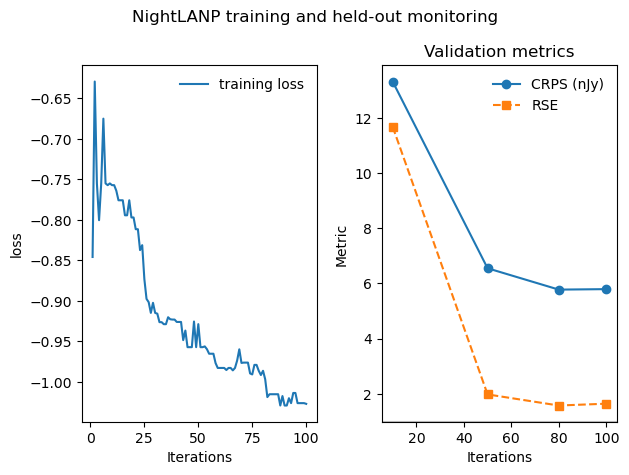

In [33]:
fig, (ax0, ax1) = plt.subplots(1, 2)
loss = history_frame["loss"].to_numpy(float)
window = max(1, min(200, len(loss) // 10))
smooth = pd.Series(loss).rolling(window, min_periods=1).median()

ax0.plot(history_frame.step, smooth, label="training loss")
ax0.set(xlabel="Iterations", ylabel="loss")
ax0.legend(frameon=False)

ax1.plot(selection.val_step, selection.crps_njy, "o-", label="CRPS (nJy)")
ax1.plot(selection.val_step, selection.rse, "s--", label="RSE")
ax1.axhline(1, color="0.75", lw=0.8)
ax1.set(
    xlabel="Iterations",
    ylabel="Metric",
    title="Validation metrics",
)
ax1.legend(frameon=False)
fig.suptitle("NightLANP training and held-out monitoring")
fig.tight_layout()
plt.show()

## 8. Inspect checkpoint results

Training differs across neural-process families and can be noisy.

We can choose the lowest median physical-nJy validation CRPS, while retaining RSE and coverage and peak timing.

In [35]:
display(selection)

viable = selection[np.isfinite(selection.crps_njy) & np.isfinite(selection.rse)]
best = viable.sort_values(["crps_njy", "val_step"]).iloc[0]
print("selected:", best.to_dict())

,val_step,crps_njy,rse,picp95_percent,peak_abs_days,finite_objects
0,10,13.326682,11.687571,100.00000,15.999999,256
1,50,6.549824,1.971961,99.21875,15.999999,256
2,80,5.775149,1.568734,98.43750,15.999999,256
3,100,5.792623,1.635199,98.43750,15.999999,256


selected: {'val_step': 80.0, 'crps_njy': 5.775149218189984, 'rse': 1.568733861427448, 'picp95_percent': 98.4375, 'peak_abs_days': 15.99999940395355, 'finite_objects': 256.0}


In [37]:
display(selection)

viable = selection[np.isfinite(selection.crps_njy) & np.isfinite(selection.rse)]
best = viable.sort_values(["crps_njy", "val_step"]).iloc[0]
print("selected:", best.to_dict())

,val_step,crps_njy,rse,picp95_percent,peak_abs_days,finite_objects
0,10,13.326682,11.687571,100.00000,15.999999,256
1,50,6.549824,1.971961,99.21875,15.999999,256
2,80,5.775149,1.568734,98.43750,15.999999,256
3,100,5.792623,1.635199,98.43750,15.999999,256


selected: {'val_step': 80.0, 'crps_njy': 5.775149218189984, 'rse': 1.568733861427448, 'picp95_percent': 98.4375, 'peak_abs_days': 15.99999940395355, 'finite_objects': 256.0}


In [45]:
nightlanp.model.load_weights(f"outputs/checkpoints/step_{val_step:06d}/model.weights.h5")
nightlanp.save("outputs/")

In [51]:
model = LightCurveNeuralProcess.load("outputs/")

## 9. Evaluate the model on hidden test set

In [54]:
X_test, y_test = benchmark_preprocessor.process_contract(test_raw, include_err=True)
fixed_test = make_fixed_val_batches(
    X_test,
    y_test,
    num_context=30,
    num_target_points=config_dict["target_points"],
    batch_size=50,
    max_batches=6,
    labels=test_labels,
    seed=seed_val,
)
test_evaluation = score_fixed_episode_batches(
    model.model,
    fixed_test,
    benchmark_preprocessor,
    num_samples=config_dict["latent_samples"],
    seed=seed_val,
    target_is_noisy=True,
)
test_metrics = test_evaluation.summary

test_summary = pd.DataFrame(
    {
        "metric": ["CRPS", "RSE", "PICP95 (%)", "reduced chi-square", "peak |dt| (days)"],
        "median": [
            test_metrics["sample_crps_median"],
            test_metrics["rse_bandmean_median"],
            test_metrics["sample_picp_median"],
            test_metrics["moment_chi2_reduced_median"],
            test_metrics["global_peak_time_absdiff_median"],
        ],
        "finite_objects": [
            test_metrics[name]
            for name in (
                "sample_crps_n_finite",
                "rse_bandmean_n_finite",
                "sample_picp_n_finite",
                "moment_chi2_reduced_n_finite",
                "global_peak_time_absdiff_n_finite",
            )
        ],
    }
)
display(test_summary)

,metric,median,finite_objects
0,CRPS,5.861061,300
1,RSE,1.621860,300
2,PICP95 (%),98.437500,300
3,reduced chi-square,0.321418,300
4,peak |dt| (days),15.999999,300


## 10. Reconstruct one completely unseen light curve in physical nJy units

We'll use the SNIIP from the NightLANP paper (object 7562).

In [56]:
test_long = lightcurves[lightcurves.split == "test"].copy()
test_long["snr"] = test_long.flux / test_long.flux_err
example_id = 7562
example = (
    test_long[test_long.objid == example_id]
    .sort_values(["mjd", "fltnum"])
    .reset_index(drop=True)
)

In [57]:
def informative_context_indices(frame, points_per_band=5):
    """Offline teaching policy: high-S/N anchors plus temporal coverage."""
    selected = []
    for band_number in range(6):
        band = frame[frame.fltnum == band_number]
        if len(band) < points_per_band:
            raise ValueError(f"band {band_number} has too few observations")
        strongest = band.nlargest(2, "snr").index.to_list()
        remaining = band.drop(index=strongest).sort_values("mjd")
        positions = np.linspace(0, len(remaining) - 1, points_per_band - 2)
        coverage = remaining.iloc[np.rint(positions).astype(int)].index.to_list()
        selected.extend(strongest + coverage)
    return np.asarray(sorted(set(selected)), dtype=int)

In [59]:
context_indices = informative_context_indices(example)
assert len(context_indices) == 30
context_long = example.iloc[context_indices].drop(columns="snr")
context_contract, _ = long_pandas_to_polars(context_long)

In [60]:
query_times = np.arange(float(example.mjd.min()), float(example.mjd.max()) + 1, 1.0)
prediction = model.predict(
    context_contract,
    target_times=query_times,
    target_bands="ugrizy",
    batch_size=1,
    num_latent_samples=config_dict["latent_samples"],
    interval_confidence=0.6827,
    std_scale=1.0,
    seed=seed_val,
)

prediction_long = prediction.explode(
    ["mjd", "fltnum", "flux", "flux_median", "flux_lower", "flux_upper"],
    empty_as_null=True,
)
prediction_long.head()

objid,mjd,fltnum,flux,flux_median,flux_lower,flux_upper,interval_confidence,predictive_std_scale,num_latent_samples
u64,f32,u8,f64,f64,f64,f64,f64,f64,i32
7562,0.0,0,2.832234,2.832234,-5.227572,12.593471,0.6827,1.0,32
7562,0.0,1,5.391637,5.391637,-2.893827,17.096832,0.6827,1.0,32
7562,0.0,2,8.995296,8.995296,-0.372295,24.798388,0.6827,1.0,32
7562,0.0,3,14.555013,14.555013,2.72597,38.454772,0.6827,1.0,32
7562,0.0,4,22.929089,22.929089,6.369769,62.008911,0.6827,1.0,32


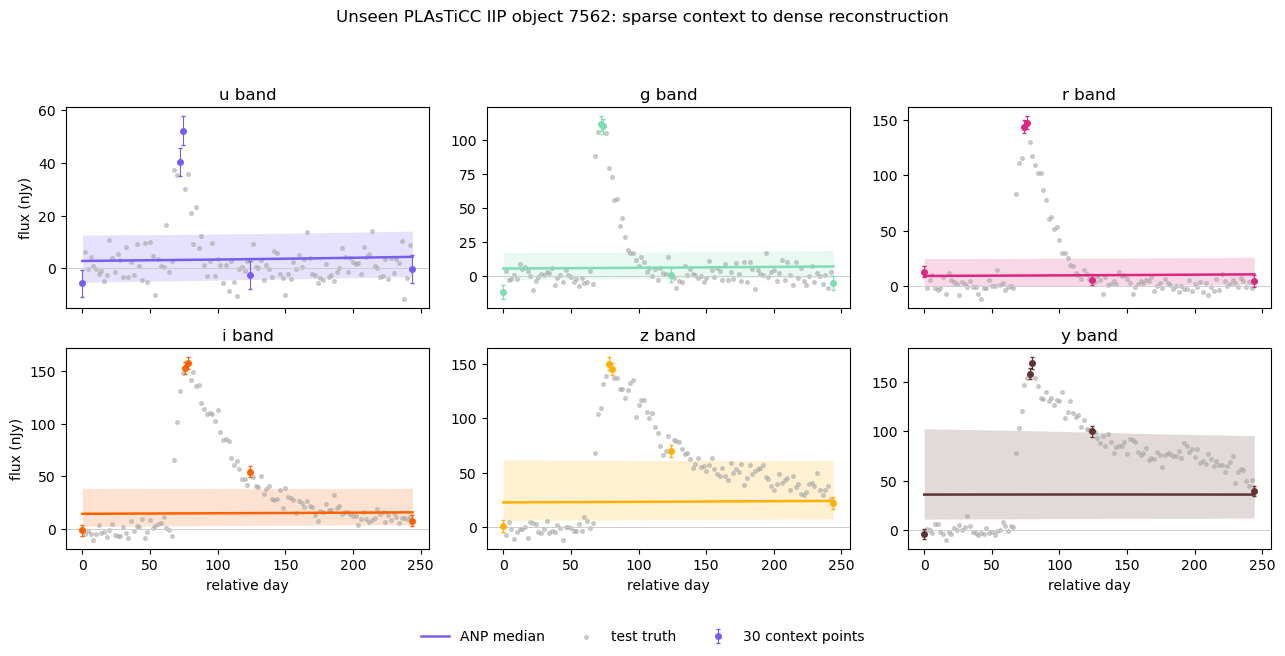

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True)
for band_number, ax in enumerate(axes.flat):
    band = translate_filternos[band_number]
    color = mycolors[band_number]
    truth = example[example.fltnum == band_number]
    observed = context_long[context_long.fltnum == band_number]
    pred = prediction_long.filter(pl.col("fltnum") == band_number)

    t = pred["mjd"].to_numpy()
    median = pred["flux_median"].to_numpy()
    lower = pred["flux_lower"].to_numpy()
    upper = pred["flux_upper"].to_numpy()
    ax.fill_between(t, lower, upper, color=color, alpha=0.18, linewidth=0)
    ax.plot(t, median, color=color, lw=1.8, label="ANP median")
    ax.scatter(truth.mjd, truth.flux, s=7, color="0.65", alpha=0.5, label="test truth")
    ax.errorbar(
        observed.mjd,
        observed.flux,
        yerr=observed.flux_err,
        fmt="o",
        ms=4,
        color=color,
        ecolor=color,
        elinewidth=0.8,
        capsize=1.5,
        label="30 context points",
        zorder=4,
    )
    ax.set_title(f"{band} band")
    ax.axhline(0, color="0.8", lw=0.7)

for ax in axes[-1]:
    ax.set_xlabel("relative day")
for ax in axes[:, 0]:
    ax.set_ylabel("flux (nJy)")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.suptitle(
    f"Unseen PLAsTiCC IIP object {example_id}: sparse context to dense reconstruction",
    y=0.99,
)
fig.tight_layout(rect=(0, 0.07, 1, 0.94))
plt.show()

## 11. Use your own dataset

You can use your own dataset with your `objid, mjd, fltnum, flux, flux_err`; everything else should follow!